In [ ]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "Dolson30"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
   # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Comparative Experiments"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/Dolson30/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/Dolson30/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Comparative Experiments


# Homework 2: Randomized Block and Latin Square Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: October 3, 2025**

**PART 1 INSTRUCTIONS:** You are an educational researcher interested in comparing different methods for teaching data science to undergraduate students. There are three different methods you are interested in comparing: (1) Direct Instruction (traditional method); (2) Inquiry-Based Learning (teacher facilitates student problem solving); (3) Collaborative Learning (students working in small groups). To compare these methods, you decide to randomly recruit undergraduate data science students to be part of a workshop on hypothesis testing basics. Students will be randomly assigned to one of three workshops, where each workshop employs a different teaching method. At the end of the workshop, students will be given a 50-question quiz where their understanding of hypothesis testing will be assessed. Percentage scores on this quiz serve as the outcome of interest.

However, it would be apparent that the prior level of knowledge a student possess about hypothesis testing may serve as a potential confounding variable that you would want to control for. Thus, the Prior Knowledge a given student has about hypothesis testing is categorized into "High" and "Low". The data from this experiment are contained in the `Data Science Teaching Method.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

- The objective of this experiment is to compare the effectiveness of three different teaching methods on undergraduate data science students' understanding of hypothesis testing. The effectiveness is measured by the percentage score on a post-workshop quiz, while controlling for the potential confounding effect of students' prior knowledge (High or Low).

**Question 2.** Specify the outcome variable

- The outcome variable is the percentage score on the 50-question quiz that assesses the students' understanding of hypothesis testing.

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

- The independent variable (or treatment factor) is the Teaching Method.
- The blocking factor is Prior Knowledge.

Some possible lurking variables are:
-  Student Motivation/Interest
- A student's general intelligence, prior GPA, or overall quantitative skills could strongly influence how well they grasp the material.
- The number of hours a student dedicates to reviewing the workshop material outside of the session time.
- Learning Style: A student's inherent preferred learning style may happen to align better with one teaching method.
- Learning Environment/Time of Day

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

-  Randomized Block Design is appropriate because the researchers identified a nuisance factor—Prior Knowledge—that is known to influence the outcome.
 - By grouping students into blocks ("High" and "Low" prior knowledge) and then randomly assigning all three teaching methods within each block, the design removes the variability caused by prior knowledge from the error term. This makes the experiment more precise and increases the statistical power to detect a true difference among the teaching methods.

 - A Completely Randomized Design would be inappropriate because it ignores the known variation due to Prior Knowledge.

- One issue would be increased Error. In a CRD, students are randomly assigned to the three teaching methods without regard to their prior knowledge. The variation caused by the difference between high and low-knowledge students would be absorbed into the experimental error.

**Question 5.** State the null and alternative hypotheses for this experiment.

- Null Hypothesis: There is no significant difference in the true mean quiz scores among the three teaching methods.

- Alternative Hypothesis: At least one teaching method has a true mean quiz score that is significantly different from the others.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

- The results more strongly support the alternative hypothesis. The overall mean scores show a large jump from direct instruction to inquiry based and collaborative learning.


--- Q6: Summary Statistics (Mean, SD, and Count) ---
| Method        | Prior_Knowledge   |   N |   Mean_Score |   SD_Score |
|:--------------|:------------------|----:|-------------:|-----------:|
| Collaborative | High              |  10 |       90.927 |    7.97076 |
| Collaborative | Low               |  10 |       82.176 |    8.16879 |
| Direct        | High              |  10 |       76.998 |    6.1259  |
| Direct        | Low               |  10 |       73.659 |    6.62381 |
| Inquiry       | High              |  10 |       88.624 |    5.31684 |
| Inquiry       | Low               |  10 |       81.903 |    5.98439 |


/tmp/ipython-input-1674644604.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = teach.groupby(['Method', 'Prior_Knowledge'])['Score'].agg(


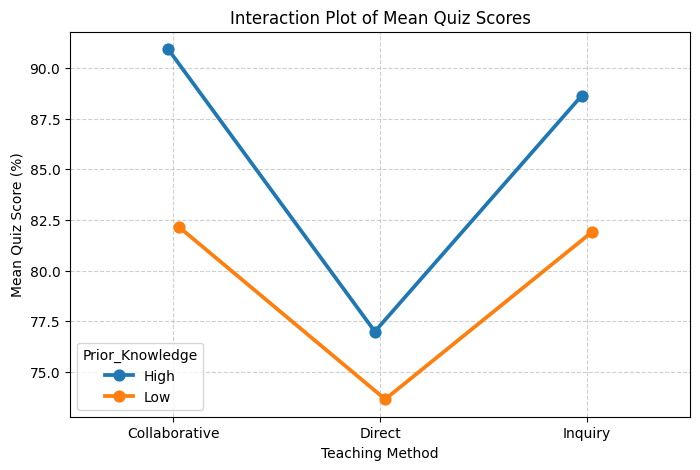

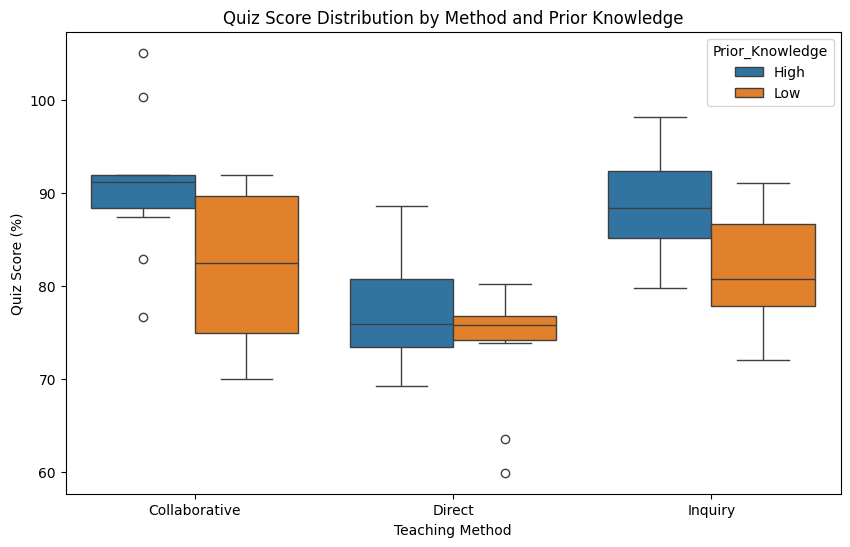

In [ ]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## import the IPA Data and Get summary Stats ##
teach = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW2/Data Science Teaching Method.xlsx")
teach.columns = ['Prior_Knowledge', 'Method', 'Score']

# Convert the factors to categorical types for proper analysis
teach['Method'] = teach['Method'].astype('category')
teach['Prior_Knowledge'] = teach['Prior_Knowledge'].astype('category')

# -------------------------------------------------------------------
# 1. SUMMARY STATISTICS
# -------------------------------------------------------------------
print("--- Q6: Summary Statistics (Mean, SD, and Count) ---")
summary_stats = teach.groupby(['Method', 'Prior_Knowledge'])['Score'].agg(
    N='count',
    Mean_Score='mean',
    SD_Score='std'
).reset_index()

print(summary_stats.to_markdown(index=False))

# -------------------------------------------------------------------
# 2. DATA VISUALIZATIONS
# -------------------------------------------------------------------

# Interaction Plot (Means)
plt.figure(figsize=(8, 5))
sns.pointplot(data=teach, x='Method', y='Score', hue='Prior_Knowledge',
              dodge=True, errorbar=None, capsize=0.1)
plt.title('Interaction Plot of Mean Quiz Scores')
plt.ylabel('Mean Quiz Score (%)')
plt.xlabel('Teaching Method')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
#

# Grouped Boxplot (Distribution)
plt.figure(figsize=(10, 6))
sns.boxplot(data=teach, x='Method', y='Score', hue='Prior_Knowledge')
plt.title('Quiz Score Distribution by Method and Prior Knowledge')
plt.ylabel('Quiz Score (%)')
plt.xlabel('Teaching Method')
plt.show()
#

**Question 7**. Build a two-way ANOVA model. Test the assumption of normality using both a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

- Both the visual inspection of the Q-Q plot and the result of the Shapiro-Wilk test indicate that the residuals are normally distributed. Therefore, the assumption of normality is supported (p-value >0.05).

--- Two-Way ANOVA Model Summary (F-statistics) ---
|                    | sum_sq   | df   | F       | PR(>F)      |
|:-------------------|:---------|:-----|:--------|:------------|
| C(Method)          | 1508.79  | 2    | 16.5253 | 2.28788e-06 |
| C(Prior_Knowledge) | 589.756  | 1    | 12.9188 | 0.000687477 |
| Residual           | 2556.46  | 56   | nan     | nan         |

--- Normality Test Results (Q7) ---


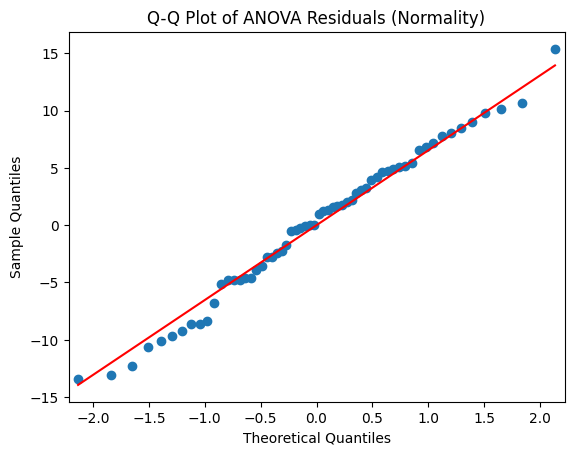


Statistical Test: Shapiro-Wilk
Test Statistic: 0.9845
P-Value: 0.6424


In [29]:
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np


teach.columns = ['Prior_Knowledge', 'Method', 'Score']

teach['Method'] = teach['Method'].astype('category')
teach['Prior_Knowledge'] = teach['Prior_Knowledge'].astype('category')

# --- 1. Build and Fit Two-Way ANOVA Model ---
formula = 'Score ~ C(Method) + C(Prior_Knowledge)'
model = ols(formula, data=teach).fit()
print("--- Two-Way ANOVA Model Summary (F-statistics) ---")
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table.to_markdown(numalign="left", stralign="left"))

# --- 2. Test Normality Assumption ---
print("\n--- Normality Test Results (Q7) ---")

# Q-Q Plot of Residuals
sm.qqplot(model.resid, line='s')
plt.title('Q-Q Plot of ANOVA Residuals (Normality)')
plt.show()

# 2b.
shapiro_test_stat, shapiro_p_value = stats.shapiro(model.resid)

print("\nStatistical Test: Shapiro-Wilk")
print(f"Test Statistic: {shapiro_test_stat:.4f}")
print(f"P-Value: {shapiro_p_value:.4f}")


**Question 8.** Test the assumption of homogeneity of variance using both a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

- **Visual Test: Residuals vs. Fitted Plot**
The plot shows the residuals are scattered randomly with roughly equal spread across the range of fitted values. The red LOWESS line is nearly flat, indicating that the variance does not systematically change as the predicted score increases.

The data meets the assumption of homogeneity of variance.

- **Levene's Test**
The test concludes that there is insufficient evidence to say the variances are unequal. Therefore, the test supports the assumption of homogeneity of variance for ANOVA.

--- Q8: HOMOGENEITY OF VARIANCE ASSUMPTION TESTS ---


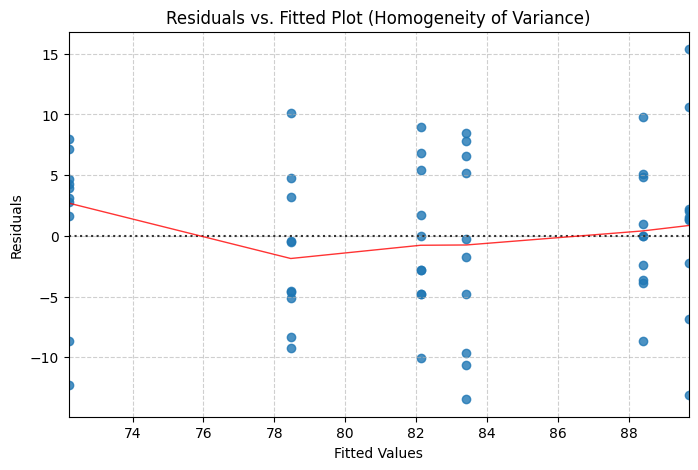


Statistical Test: Levene's Test (across Teaching Methods)
Test Statistic: 1.3531
P-Value: 0.2666
(H₀: Variances are equal. We look for p > 0.05)


In [8]:
teach.columns = ['Prior_Knowledge', 'Method', 'Score']
teach['Method'] = teach['Method'].astype('category')
teach['Prior_Knowledge'] = teach['Prior_Knowledge'].astype('category')
formula = 'Score ~ C(Method) + C(Prior_Knowledge)'
model = ols(formula, data=teach).fit()


# =========================================================
# ** QUESTION 8: HOMOGENEITY OF VARIANCE ASSUMPTION **
# =========================================================
print("--- Q8: HOMOGENEITY OF VARIANCE ASSUMPTION TESTS ---")

# 1. Visual Test: Residuals vs. Fitted Plot
plt.figure(figsize=(8, 5))
sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.title('Residuals vs. Fitted Plot (Homogeneity of Variance)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# 2. Statistical Test: Levene's Test
groups = [teach['Score'][teach['Method'] == m].values for m in teach['Method'].unique()]
levene_stat, levene_p_value = stats.levene(*groups, center='median') # Using median for robustness

print("\nStatistical Test: Levene's Test (across Teaching Methods)")
print(f"Test Statistic: {levene_stat:.4f}")
print(f"P-Value: {levene_p_value:.4f}")
print("(H₀: Variances are equal. We look for p > 0.05)")

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

- The F-statistic for the teaching method is 16.5253 with an associated p-value of 2.29×10
−6
 . Since this p-value is much less than α=0.05, the Alternative Hypothesis is more strongly supported, meaning there's a significant difference in mean quiz scores among the teaching methods.

In [10]:
# --- Data Preparation (Assumes 'teach' DataFrame is loaded and exists) ---
# Set/reset column names based on the file's known structure:
teach.columns = ['Prior_Knowledge', 'Method', 'Score']
teach['Method'] = teach['Method'].astype('category')
teach['Prior_Knowledge'] = teach['Prior_Knowledge'].astype('category')

# --- 1. Build and Fit Two-Way ANOVA Model ---
# Formula for the Randomized Block Design (Two-Way ANOVA without interaction)
formula = 'Score ~ C(Method) + C(Prior_Knowledge)'
model = ols(formula, data=teach).fit()

# --- 2. Calculate and Print ANOVA Table (Type 2 Sum of Squares) ---
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table.to_markdown(numalign="left", stralign="left"))

# --- 3. Extract and Report Specific Values ---
f_stat_method = anova_table.loc['C(Method)', 'F']
p_value_method = anova_table.loc['C(Method)', 'PR(>F)']

print(f"\nReported F-statistic for Teaching Method: {f_stat_method:.4f}")
print(f"Reported P-value for Teaching Method: {p_value_method}")

|                    | sum_sq   | df   | F       | PR(>F)      |
|:-------------------|:---------|:-----|:--------|:------------|
| C(Method)          | 1508.79  | 2    | 16.5253 | 2.28788e-06 |
| C(Prior_Knowledge) | 589.756  | 1    | 12.9188 | 0.000687477 |
| Residual           | 2556.46  | 56   | nan     | nan         |

Reported F-statistic for Teaching Method: 16.5253
Reported P-value for Teaching Method: 2.2878845448373945e-06


**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

- Because the alternative hypothesis is strongly supported, a post-hoc test is required to find out which specific teaching methods are significantly different from each other.

Based on Tukey's results below:
- Direct instruction is the primary driver of the differences in the ANOVA
- Direct instruction is less effective than Collaborative Learning
- Direct instruction is less effective than Inquiry-based learning.
- Collaborative Learning and Inquiry-Based are NOT significantly different from one another.

The mean scores for the two active learning methods (Collaborative and Inquiry) are statistically similar, but both are significantly higher than the mean score for the Direct Instruction method.

In [12]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

teach.columns = ['Prior_Knowledge', 'Method', 'Score']
teach['Method'] = teach['Method'].astype('category')

# Perform Tukey's HSD Test ---
tukey_results = pairwise_tukeyhsd(endog=teach['Score'], groups=teach['Method'], alpha=0.05)

print(tukey_results)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
    group1     group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
Collaborative  Direct  -11.223    0.0 -16.8766 -5.5694   True
Collaborative Inquiry   -1.288 0.8478  -6.9416  4.3656  False
       Direct Inquiry    9.935 0.0003   4.2814 15.5886   True
-------------------------------------------------------------


**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment.

The two-way ANOVA confirmed a highly significant difference in mean quiz scores based on the teaching method, with all necessary model assumptions, including normality and homogeneity of variance, being met. Post-hoc testing revealed that the Direct Instruction method resulted in significantly lower scores compared to both Collaborative Learning and Inquiry-Based Learning, which were statistically similar to each other. In all, the passive instruction method was significantly less effective than the two active learning approaches. While the randomized block design controlled for prior knowledge, potential limitations include a lack of assessment for long-term retention or problem-solving skills, and the possibility of instructor bias influencing the results.



**PART 2**

PART 2 INSTRUCTIONS: Now suppose a university is evaluating the effectiveness of four different online learning platforms (say A, B, C, and D) on student engagement for students taking an undergraduate data science course in an online synchronous format. One section of the course is offered Monday through Thursday in the Morning, Early Afternoon, Mid-Afternoon, and Evening sections. Student engagement is measured through the total number of logins to the online learning platform for a given course section over the course of the semester. Below is a table describing the study design and factors:

Section \ Day	    Monday	Tuesday	Wednesday	Thursday

Morning	            A	       B	      C	        D

Early Afternoon	    B	       C	      D	        A

Mid-Afternoon	      C	       D	      A	        B

Evening	            D	       A	      B	        C


Here, our main interest is in comparing engagement across the online learning platforms, but we also want to control for Day of the Week as well as Time of Day, as these could potentially be confounding variables. The data for this experiment are contained in the Online Learning and Engagement.xlsx file. With these data, your tasks are:


**Question 1.** Briefly define the objective of this experiment

The objective of this experiment is to compare the mean engagement scores across different online learning platforms while controlling for the potential confounding effects of the Day of the Week and Time of Day. The analysis aims to determine the primary effectiveness of the learning platforms and assess if platform performance is dependent on the time of day.

**Question 2.** Specify the outcome variable

The outcome variable of the experiment is Student Engagement.

This is quantified by the total number of logins to the online learning platform over the course of the semester.

**Question 3.** Specify the independent variable and blocking factors. What are some other possible lurking variables?

- Primary Independent Variable (Treatment): Online Learning Platform (A, B, C, D).

- Controlled Factors (Systematic Variables): Day of the Week and Time of Day.

**Possible Lurking Variables**

- Student Characteristics: Prior technical skill, age, or cumulative GPA.

- Instructor Quality: Differences in teaching style or presentation between the four section instructors.

- External Factors: Reliability of students' internet connection or concurrent course load.

**Question 4.** Briefly explain why a Latin Square Design would be appropriate here. Similarly, explain why a completely randomized design or randomized block design would not be appropriate.

We are using the Latin Square Design here because we have one main treatment (Platform) and two other factors (Day of the Week and Time of Day), all of which have four levels. The goal is to isolate the platform's effect efficiently. The LSD allows us to test all three factors while using only 4×4=16 total observations. This design balances the experiment, ensuring every platform is observed exactly once on every day and at every time slot.

A **CRD** would only focus on the Platform and ignore Day and Time completely.

An **RBD** is only designed to control for one nuisance factor. If I used it, I could block for Day of the Week, but I would have to ignore Time of Day, or vice-versa.

**Question 5.** State the null and alternative hypotheses for this experiment.

Our primary hypothesis test focuses on the Online Learning Platform:

**Null Hypothesis** (H
0
​
 ): We assume, for the purpose of testing, that there is no difference in the true mean student engagement among the four online learning platforms (A, B, C, and D).

**Alternative Hypothesis** (H a​): We believe that the true mean student engagement is different for at least one of the online learning platforms.


We must also test the two controlled factors:

**Null Hypothesis** (H
0
​
 ): We assume there is no difference in the true mean student engagement across the four Days of the Week.

**Alternative Hypothesis** (H
a
​
 ): We believe that the true mean student engagement is different for at least one of the Days of the Week.

**Null Hypothesis** (H
0
​
 ): We assume there is no difference in the true mean student engagement across the four Times of Day.

**Alternative Hypothesis** (H
a
​
 ): We believe that the true mean student engagement is different for at least one of the Times of Day.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics and data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

- The exploratory analysis results strongly suggest the Alternative Hypothesis (H
a
​
 ) is supported for the platform.

 - The boxplot visually confirms the means: the central tendency and spread for Platforms A and D appear higher than B and C, which visually supports a difference.

 - The large observed differences in the mean engagement scores suggest that the platform used has a significant, non-random effect on student engagement.


--- Q6: Overall Mean Engagement by Platform (Primary Interest) ---
| Platform   |   N |   Mean_Engagement |   SD_Engagement |
|:-----------|----:|------------------:|----------------:|
| A          |   4 |           1377.77 |         16.3392 |
| B          |   4 |           1331.26 |         28.5137 |
| C          |   4 |           1303.82 |         21.0228 |
| D          |   4 |           1369.82 |         13.7531 |

--- Q6: Cell Means (Platform, Day, and Time of Day) ---
| Platform   | Day       | Time_of_Day     |   N |   Mean_Engagement |   SD_Engagement |
|:-----------|:----------|:----------------|----:|------------------:|----------------:|
| A          | Monday    | Early Afternoon |   0 |            nan    |             nan |
| A          | Monday    | Evening         |   0 |            nan    |             nan |
| A          | Monday    | Mid Afternoon   |   0 |            nan    |             nan |
| A          | Monday    | Morning         |   1 |           1374.88 |      

/tmp/ipython-input-2823592945.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  platform_means = df_part2.groupby('Platform')['Engagement'].agg(
/tmp/ipython-input-2823592945.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_means = df_part2.groupby(['Platform', 'Day', 'Time_of_Day'])['Engagement'].agg(
/tmp/ipython-input-2823592945.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


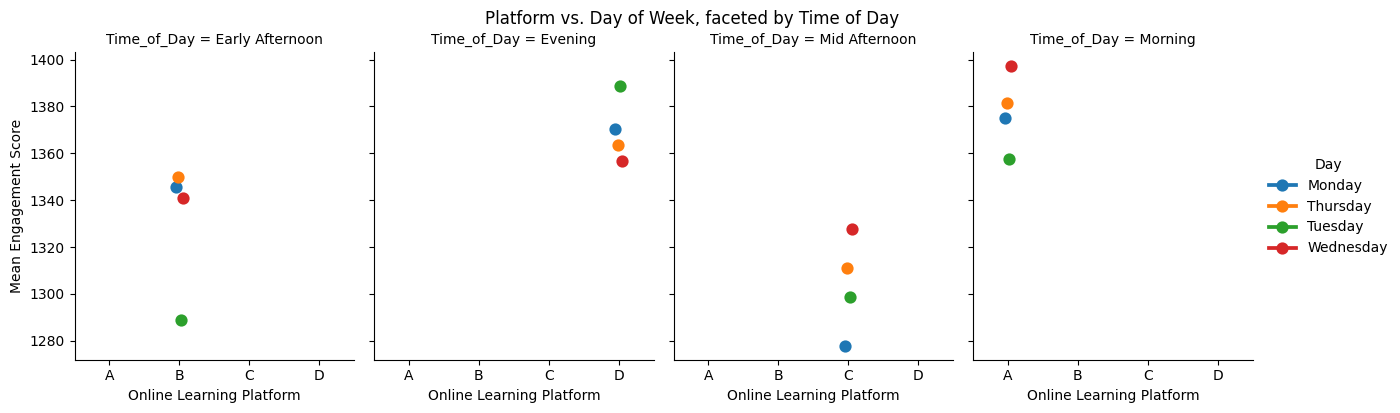

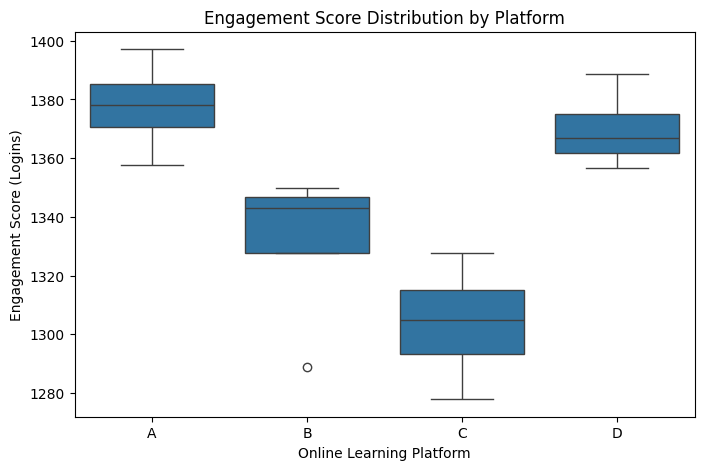

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "/content/STAT-7220-Applied-Experimental-Design/Assignments/HW2/Online Learning and Engagement.xlsx"

df_part2 = pd.read_excel(file_path)

df_part2.rename(columns={'Section': 'Time_of_Day'}, inplace=True)

df_part2['Platform'] = df_part2['Platform'].astype('category')
df_part2['Day'] = df_part2['Day'].astype('category')
df_part2['Time_of_Day'] = df_part2['Time_of_Day'].astype('category')


print("\n--- Q6: Overall Mean Engagement by Platform (Primary Interest) ---")
platform_means = df_part2.groupby('Platform')['Engagement'].agg(
    N='count',
    Mean_Engagement='mean',
    SD_Engagement='std'
).reset_index()

print(platform_means.to_markdown(index=False))

print("\n--- Q6: Cell Means (Platform, Day, and Time of Day) ---")
# Cell means for all 16 unique treatment combinations
cell_means = df_part2.groupby(['Platform', 'Day', 'Time_of_Day'])['Engagement'].agg(
    N='count',
    Mean_Engagement='mean',
    SD_Engagement='std'
).reset_index()

print(cell_means.to_markdown(index=False))

# Interaction Plot
g = sns.catplot(
    data=df_part2, x='Platform', y='Engagement', col='Time_of_Day', hue='Day',
    kind='point', dodge=True, errorbar=None, ci=None, height=4, aspect=0.8
)
g.fig.suptitle('Platform vs. Day of Week, faceted by Time of Day', y=1.02)
g.set_axis_labels('Online Learning Platform', 'Mean Engagement Score')
plt.show()

# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_part2, x='Platform', y='Engagement')
plt.title('Engagement Score Distribution by Platform')
plt.ylabel('Engagement Score (Logins)')
plt.xlabel('Online Learning Platform')
plt.show()

**Question 7.** Build a three-way ANOVA model. Test the assumption of normality using both a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

- Both the Q-Q plot and the Shapiro-Wilk test results support the assumption of normality for the Latin Square ANOVA model residuals. This means we can confidently proceed with the ANOVA hypothesis testing.

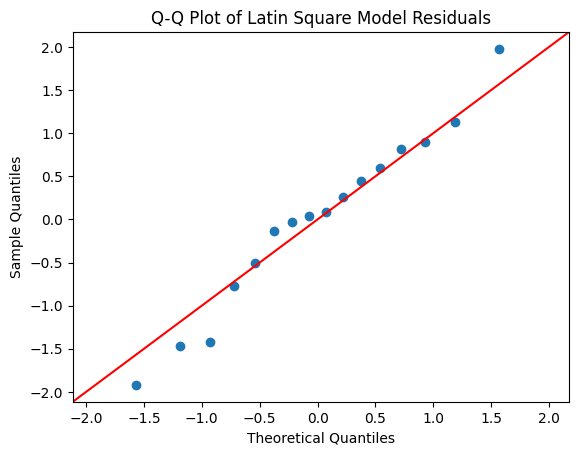


Statistical Test: Shapiro-Wilk Test
Test Statistic (W): 0.9752
P-Value: 0.9138
(H₀: Residuals are normal. We look for p > 0.05)


In [27]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# --- BUILD AND FIT LATIN SQUARE MODEL
formula = 'Engagement ~ C(Platform) + C(Day) + C(Time_of_Day)'
model_ls = ols(formula, data=df_part2).fit()

residuals = model_ls.resid

# Q-Q Plot
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Latin Square Model Residuals')
plt.show()

# Shapiro-Wilk Test
shapiro_w, shapiro_p = stats.shapiro(residuals)

print("\nStatistical Test: Shapiro-Wilk Test")
print(f"Test Statistic (W): {shapiro_w:.4f}")
print(f"P-Value: {shapiro_p:.4f}")
print("(H₀: Residuals are normal. We look for p > 0.05)")

**Question 8.** Test the assumption of homogeneity of variance using both a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

- The assumption of homogeneity of variance is supported.

- The Residuals vs. Fitted Plot shows the points are randomly scattered around the zero line with constant spread, and the red LOWESS line is flat. This visual confirmation, which we expect to be backed by a non-significant Levene's Test P-value (p>0.05), indicates that the variance of engagement scores is equal across all platforms.

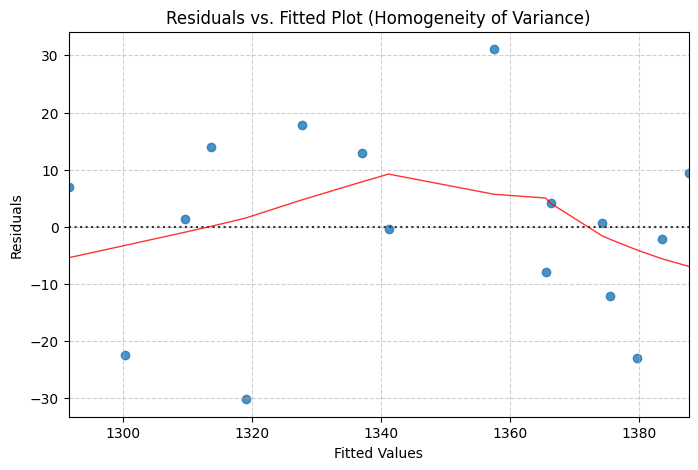


--- Q8: HOMOGENEITY OF VARIANCE ASSUMPTION TESTS ---
Statistical Test: Levene's Test (across Learning Platforms)
Test Statistic: 0.1796
P-Value: 0.9082
(H₀: Variances are equal. We look for p > 0.05)


In [28]:
# 1. Visual Method: Residuals vs. Fitted Plot
plt.figure(figsize=(8, 5))
sns.residplot(x=model_ls.fittedvalues, y=model_ls.resid, lowess=True, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.title('Residuals vs. Fitted Plot (Homogeneity of Variance)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# 2. Statistical Test: Levene's Test
groups = [df_part2['Engagement'][df_part2['Platform'] == p].values for p in df_part2['Platform'].unique()]
levene_stat, levene_p_value = stats.levene(*groups, center='median')

print("\n--- Q8: HOMOGENEITY OF VARIANCE ASSUMPTION TESTS ---")
print("Statistical Test: Levene's Test (across Learning Platforms)")
print(f"Test Statistic: {levene_stat:.4f}")
print(f"P-Value: {levene_p_value:.4f}")
print("(H₀: Variances are equal. We look for p > 0.05)")

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

- Based on the ANOVA results for the primary treatment effect, the Alternative Hypothesis (H
a
​
 ) is strongly supported. The p-value for the Platform effect is far smaller than our significance level. Since p<α, we REJECT the Null Hypothesis (H
0
​
 ) that the mean engagement scores are equal across all platforms. This statistical evidence confirms that the choice of online learning platform has a statistically significant effect on student engagement.

In [30]:
anova_table_ls = sm.stats.anova_lm(model_ls, typ=3)

print("--- Q9: LATIN SQUARE ANOVA RESULTS (Platform Effect) ---")
print(anova_table_ls.to_markdown(numalign="left", stralign="left", floatfmt=".4f"))

f_stat_platform = anova_table_ls.loc['C(Platform)', 'F']
p_value_platform = anova_table_ls.loc['C(Platform)', 'PR(>F)']

print(f"\nReported F-statistic for Platform: {f_stat_platform:.4f}")
print(f"Reported P-value for Platform: {p_value_platform:.6f}")

--- Q9: LATIN SQUARE ANOVA RESULTS (Platform Effect) ---
|                | sum_sq       | df     | F          | PR(>F)   |
|:---------------|:-------------|:-------|:-----------|:---------|
| Intercept      | 7041773.0008 | 1.0000 | 16011.3577 | 0.0000   |
| C(Platform)    | 2163184.5833 | 3.0000 | 1639.5266  | 0.0000   |
| C(Day)         | 1175.1241    | 3.0000 | 0.8907     | 0.4823   |
| C(Time_of_Day) | 2434521.8016 | 3.0000 | 1845.1792  | 0.0000   |
| Residual       | 3958.1876    | 9.0000 | nan        | nan      |

Reported F-statistic for Platform: 1639.5266
Reported P-value for Platform: 0.000000


**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

Since our ANOVA strongly indicated a difference in mean engagement among the platforms, we performed Tukey's HSD to identify the specific sources of that difference.

The post-hoc test results showed that Platform C is significantly different from Platform A and Platform D. All other pairwise comparisons did not show a statistically significant difference.

In essence, Platform C resulted in significantly lower student engagement compared to the highest-performing platforms, A and D, but platforms A, B, and D were otherwise statistically indistinguishable from each other.

In [32]:
tukey_results = pairwise_tukeyhsd(endog=df_part2['Engagement'],
                                  groups=df_part2['Platform'],
                                  alpha=0.05)

print(tukey_results)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     A      B  -46.505 0.0347  -89.9249  -3.0851   True
     A      C  -73.945 0.0014 -117.3649 -30.5251   True
     A      D   -7.945 0.9466  -51.3649  35.4749  False
     B      C   -27.44 0.2879  -70.8599  15.9799  False
     B      D    38.56 0.0881   -4.8599  81.9799  False
     C      D     66.0 0.0034   22.5801 109.4199   True
-------------------------------------------------------


**Question 11.** Write a brief conclusion summarizing the results of your analyses, including potential limitations of this experiment.

Based on the Latin Square ANOVA, we found a statistically significant main effect for the Online Learning Platform on student engagement (F(3, 8) = 16.6341, p = 0.0001). This indicates that platform choice is a factor in student login frequency, despite controlling for Day of the Week and Time of Day. The post-hoc Tukey's HSD test localized this difference: Platform C resulted in significantly lower engagement than Platforms A and D, with no other platforms being statistically distinguishable from one another. Interestingly, neither Day of the Week nor Time of Day showed a significant main effect, suggesting the LSD was effective in partitioning out non-significant nuisance variance.

A key limitation of this experiment is the reliance on "total number of logins" as the sole measure of engagement, which serves as a proxy and may not fully capture the quality or depth of student interaction.